# Stage 3 — Exploratory Data Analysis (EDA)

## Purpose
Understand the structure, distributions, and relationships in the cleaned
dataset before building any models. Every chart here answers a specific
business question and will inform a modelling decision later.

## Questions We Are Answering
1. How severe is the churn rate? Is there a class imbalance?
2. How are numeric features (tenure, charges) distributed?
3. Which customer segments have the highest churn rates?
4. Are any features strongly correlated with each other?
5. How do numeric features differ between churned and retained customers?

## Output
All figures saved to: reports/figures/

In [3]:
# Import all libraries

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

#styling
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi']     = 120
plt.rcParams['savefig.dpi']   = 150
plt.rcParams['figure.facecolor'] = 'white'

#Paths
DATA_PATH    = '../data/processed/churn_cleaned.csv'
FIGURES_PATH = '../reports/figures/'
os.makedirs(FIGURES_PATH, exist_ok=True)

print("Setup complete. All libraries loaded.")
print(f"Figures will be saved to: {FIGURES_PATH}")

Setup complete. All libraries loaded.
Figures will be saved to: ../reports/figures/


In [4]:
# Load the cleaned data and doa a final sanity check

df = pd.read_csv(DATA_PATH)

print(f"Shape          : {df.shape}")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"Churn values   : {df['Churn'].unique()}")
print(f"\nColumn overview:")
print(df.dtypes.to_string())


Shape          : (7032, 20)
Missing values : 0
Churn values   : [0 1]

Column overview:
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling      int64
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64


In [5]:
# Calculate churn statistics

churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

print("=" * 40)
print(" CHURN DISTRIBUTION SUMMARY")
print("=" * 40)
print(f"  Total customers   : {len(df):,}")
print(f"  Retained (0)      : {churn_counts[0]:,}  ({churn_pct[0]:.1f}%)")
print(f"  Churned (1)      : {churn_counts[1]:,}  ({churn_pct[1]:.1f}%)")
print(f" Imbalance ratio   : {churn_counts[0]/churn_counts[1]:.1f}:1")
print("=" * 40)
print()
print("INSIGHT: The dataset is moderately imbalanced.")
print("We have ~2.7x more retained customers than churned.")
print("This MUST be handled in model training (Stage 5).")

 CHURN DISTRIBUTION SUMMARY
  Total customers   : 7,032
  Retained (0)      : 5,163  (73.4%)
  Churned (1)      : 1,869  (26.6%)
 Imbalance ratio   : 2.8:1

INSIGHT: The dataset is moderately imbalanced.
We have ~2.7x more retained customers than churned.
This MUST be handled in model training (Stage 5).


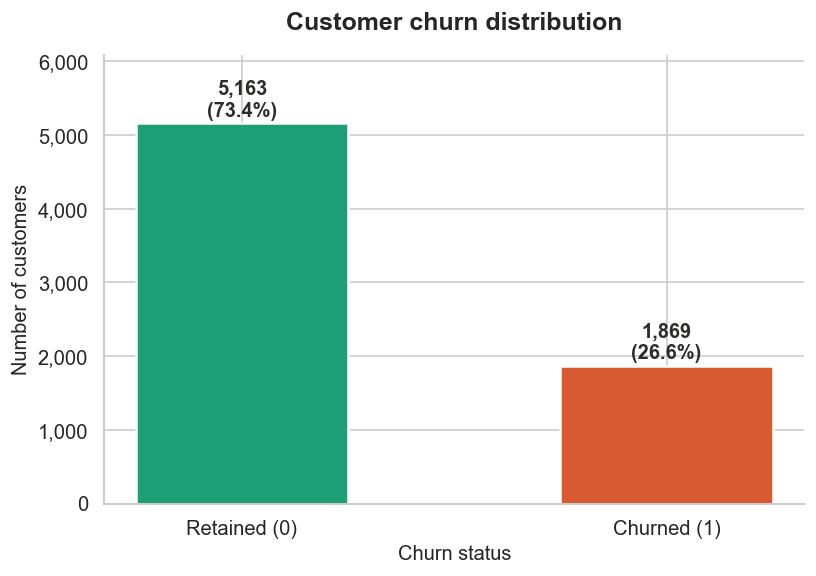

Saved: 01_churn_distribution.png


In [6]:
# Plot the churn distribution (bar chart)

fig, ax = plt.subplots(figsize=(7, 5))

# Define colours
colors = ['#1D9E75', '#D85A30']
labels = ['Retained (0)', 'Churned (1)']
values = [churn_counts[0], churn_counts[1]]

bars = ax.bar(labels, values, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

# Add count and percentage label on top of each bar
for bar, val, pct in zip(bars, values, churn_pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 40,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom',
            fontsize=12, fontweight='bold', color='#2C2C2A')
    
# Labels and formatting
ax.set_title('Customer churn distribution', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Churn status', fontsize=12)
ax.set_ylabel('Number of customers', fontsize=12)
ax.set_ylim(0, max(values) * 1.18)   # extra space for labels above bars
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}01_churn_distribution.png', bbox_inches='tight')
plt.show()
print("Saved: 01_churn_distribution.png")
    


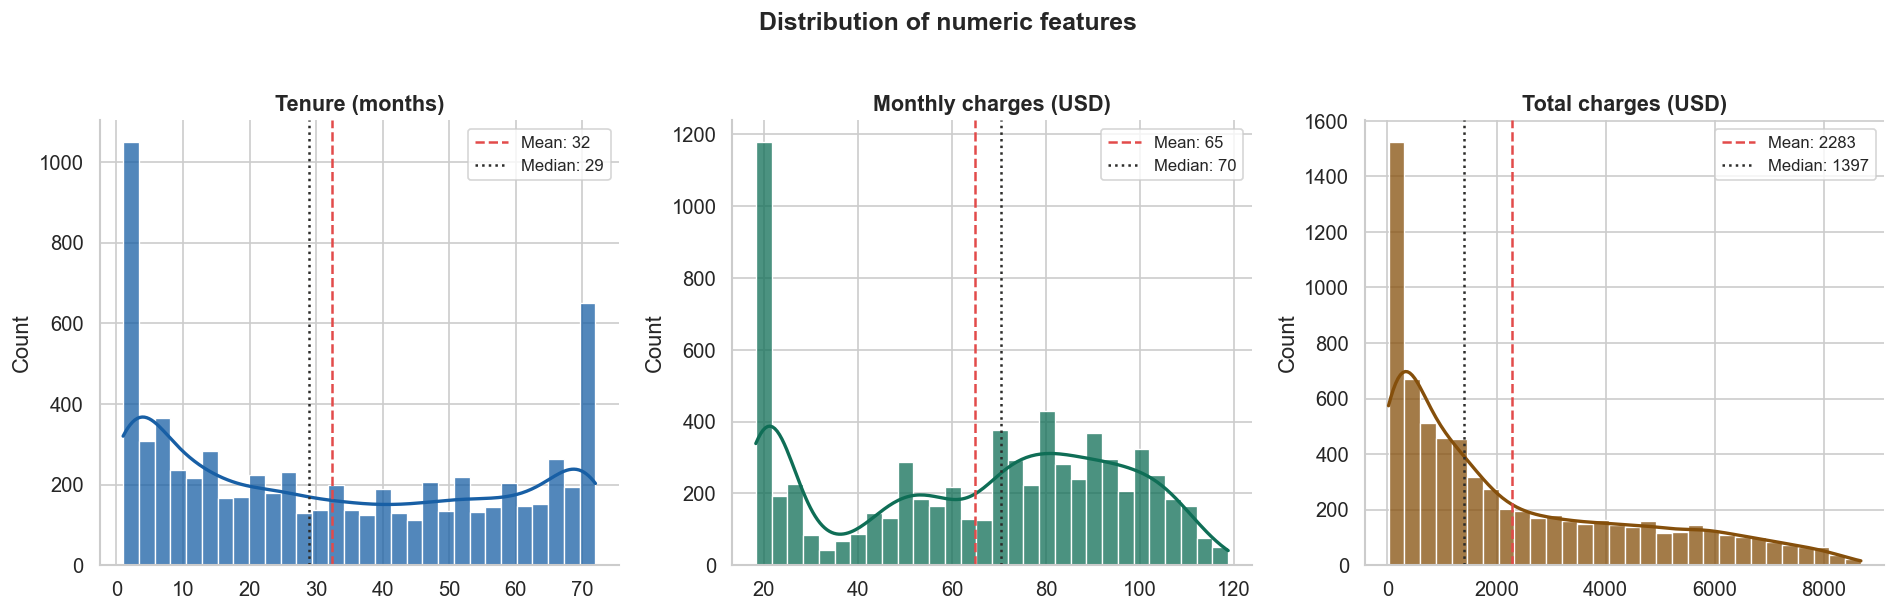

Saved: 02_numeric_distributions.png


In [10]:
# Histograms for the three numeric features
numeric_cols  = ['tenure', 'MonthlyCharges', 'TotalCharges']
col_colors    = ['#185FA5', '#0F6E56', '#854F0B']
col_titles    = ['Tenure (months)', 'Monthly charges (USD)', 'Total charges (USD)']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, color, title in zip(axes, numeric_cols, col_colors, col_titles):
    sns.histplot(data=df, x=col, kde=True, ax=ax, color=color,
                 alpha=0.75, bins=30, line_kws={'linewidth': 2})

    # Add vertical mean and median lines 
    mean_val   = df[col].mean()
    median_val = df[col].median()
 
    ax.axvline(mean_val, color='#E24B4A', linestyle='--',
               linewidth=1.5, label=f'Mean: {mean_val:.0f}')
    ax.axvline(median_val, color='#2C2C2A', linestyle=':',
               linewidth=1.5, label=f'Median: {median_val:.0f}')
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=10)
    sns.despine(ax=ax)

fig.suptitle('Distribution of numeric features', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}02_numeric_distributions.png', bbox_inches='tight')
plt.show()
print("Saved: 02_numeric_distributions.png")

In [13]:
# Print the statistical summary and record insights

print("Statistical summary and record insights")
print(df[numeric_cols].describe().round(2))
print()
print("Skewness (how lopsided each distribution is):")
print(df[numeric_cols].skew().round(3))
print()
print("INSIGHTS:")
print("  tenure          : Bimodal - peaks at ~1 month and ~70 months.")
print("                  : Many new customers and many very loyal ones.")
print("  MonthlyCharges  : Roughly uniform - spread across the full range.")
print("  TotalCharges    : Right-skewed -  most customers heave low totals,")
print("                  : a few long-tenure customers have very high totals.")

Statistical summary and record insights
        tenure  MonthlyCharges  TotalCharges
count  7032.00         7032.00       7032.00
mean     32.42           64.80       2283.30
std      24.55           30.09       2266.77
min       1.00           18.25         18.80
25%       9.00           35.59        401.45
50%      29.00           70.35       1397.48
75%      55.00           89.86       3794.74
max      72.00          118.75       8684.80

Skewness (how lopsided each distribution is):
tenure            0.238
MonthlyCharges   -0.222
TotalCharges      0.962
dtype: float64

INSIGHTS:
  tenure          : Bimodal - peaks at ~1 month and ~70 months.
                  : Many new customers and many very loyal ones.
  MonthlyCharges  : Roughly uniform - spread across the full range.
  TotalCharges    : Right-skewed -  most customers heave low totals,
                  : a few long-tenure customers have very high totals.


In [16]:
# Churn rate by Contract type

contract_churn = (df.groupby('Contract')['Churn']
                    .mean()
                    .mul(100)
                    .reset_index()
                    .rename(columns={'Churn': 'ChurnRate'})
                    .sort_values('ChurnRate', ascending=False))

print("Churn rate by contract type")
print(contract_churn.to_string(index=False))

Churn rate by contract type
      Contract  ChurnRate
Month-to-month  42.709677
      One year  11.277174
      Two year   2.848665


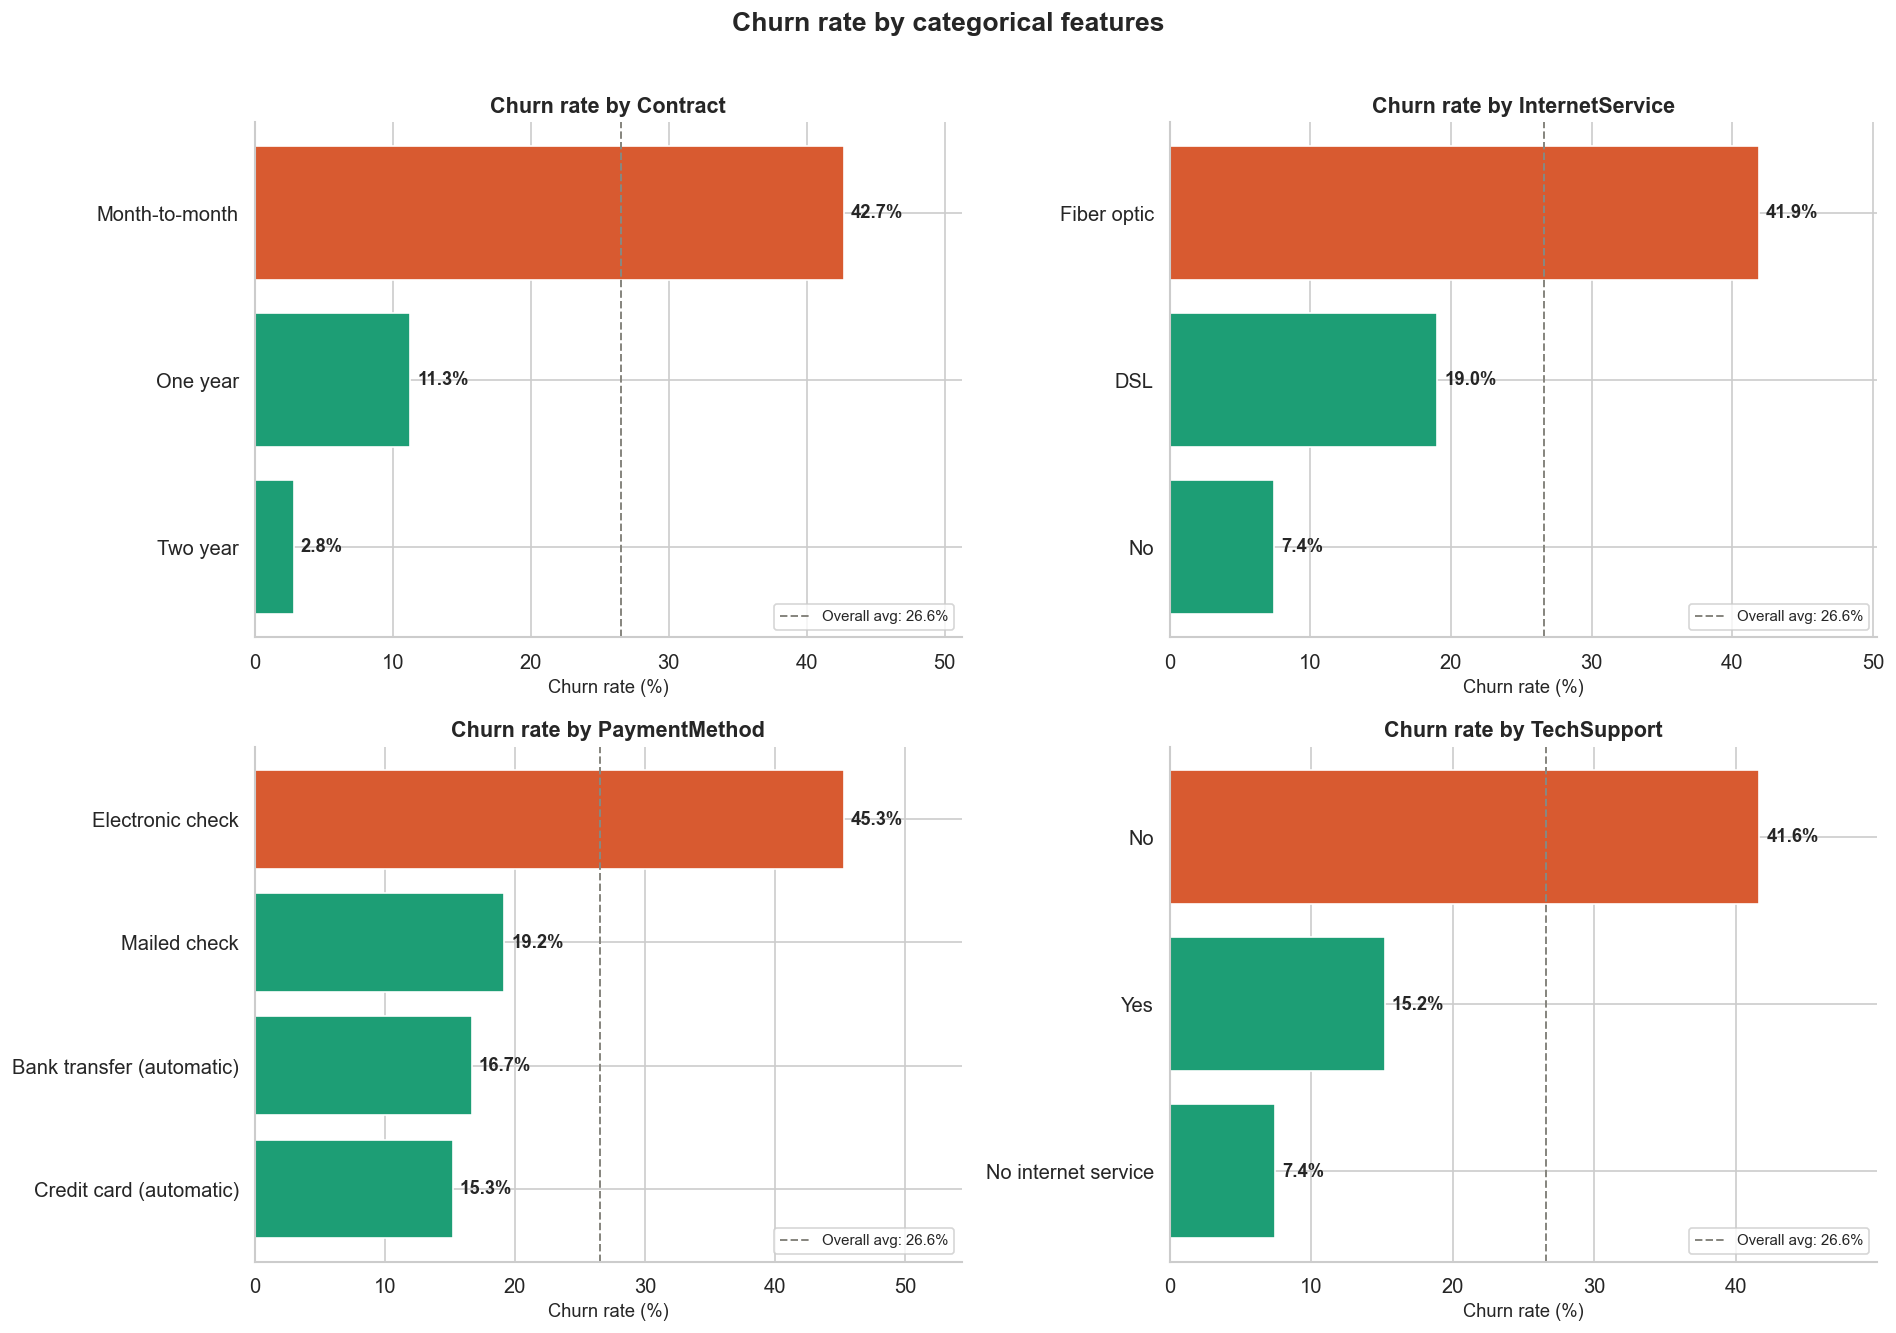

Saved: 03_categorical_churn_rates.png


In [17]:
# Churn rate bar charts for all key categorical columns

categorical_to_plot = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for ax, col in zip(axes, categorical_to_plot):
    churn_by_cat = (df.groupby(col)['Churn']
                      .mean()
                      .mul(100)
                      .reset_index()
                      .rename(columns={'Churn': 'ChurnRate'})
                      .sort_values('ChurnRate', ascending=True))
    
    # color list->red red for rates above overall average,  teal otherwise
    overall_rate = df['Churn'].mean() * 100
    bar_colors   = ['#D85A30' if r > overall_rate else '#1D9E75'
                    for r in churn_by_cat['ChurnRate']]
    bars = ax.barh(churn_by_cat[col], churn_by_cat['ChurnRate'],
                   color=bar_colors, edgecolor='white', linewidth=1)

    # Add percentage labels at the end of each bar
    for bar, val in zip(bars, churn_by_cat['ChurnRate']):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')

    # Add a vertical dashed line at the overall churn rate for reference
    ax.axvline(overall_rate, color='#888780', linestyle='--',
               linewidth=1.2, label=f'Overall avg: {overall_rate:.1f}%')

    ax.set_title(f'Churn rate by {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Churn rate (%)', fontsize=11)
    ax.set_xlim(0, churn_by_cat['ChurnRate'].max() * 1.2)
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

fig.suptitle('Churn rate by categorical features', fontsize=16,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}03_categorical_churn_rates.png', bbox_inches='tight')
plt.show()
print("Saved: 03_categorical_churn_rates.png")
            

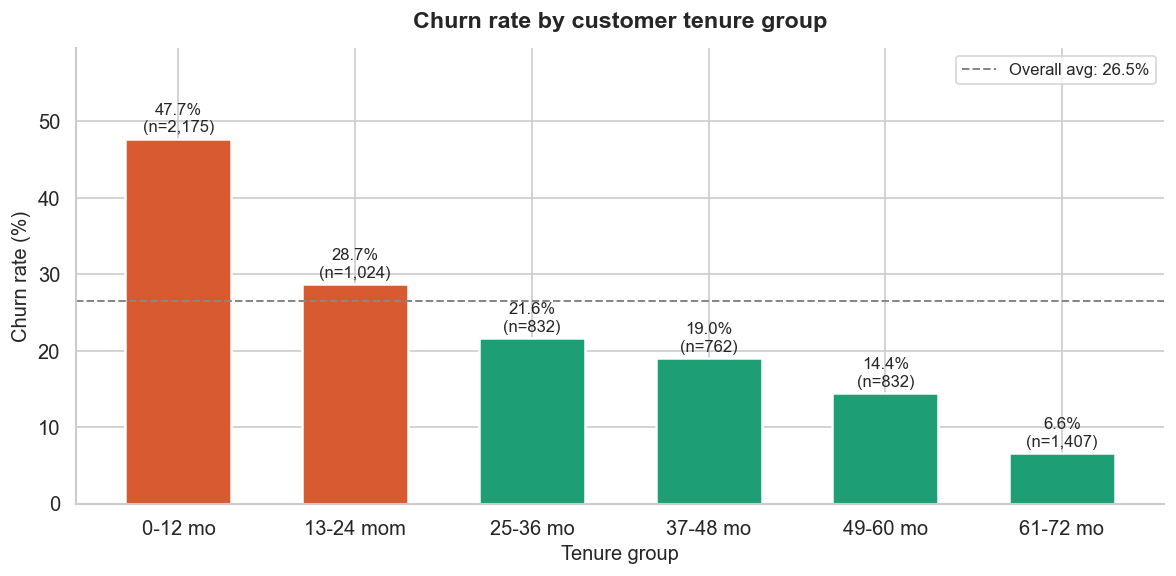

Saved: 04_churn_by_tenure_group.png


In [19]:
# Churn rates by Tenure group (bucketed)

df['tenure_group'] = pd.cut(
    df['tenure'],
    bins   = [0, 12, 24, 36, 48, 60, 72],
    labels = ['0-12 mo', '13-24 mom', '25-36 mo',
              '37-48 mo', '49-60 mo', '61-72 mo'],
    include_lowest=True
)

tenure_churn = (df.groupby('tenure_group', observed=True)['Churn']
                .agg(['mean', 'count'])
                .reset_index()
                .rename(columns={'mean': 'ChurnRate', 'count': 'CustomerCount'}))
tenure_churn['ChurnRate'] *= 100

fig, ax = plt.subplots(figsize=(10, 5))

bar_colors = ['#D85A30' if r > 26.5 else '#1D9E75'
              for r in tenure_churn['ChurnRate']]

bars = ax.bar(tenure_churn['tenure_group'].astype(str),
              tenure_churn['ChurnRate'],
              color=bar_colors, width=0.6,
              edgecolor='white', linewidth=1.5)

# Label each bar with count and churn %
for bar, row in zip(bars, tenure_churn.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{row.ChurnRate:.1f}%\n(n={row.CustomerCount:,})',
            ha='center', va='bottom', fontsize=10)

ax.axhline(26.5, color='#888780', linestyle='--',
           linewidth=1.2, label='Overall avg: 26.5%')
ax.set_title('Churn rate by customer tenure group',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Tenure group', fontsize=12)
ax.set_ylabel('Churn rate (%)', fontsize=12)
ax.set_ylim(0, tenure_churn['ChurnRate'].max() * 1.25)
ax.legend(fontsize=10)
sns.despine()

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}04_churn_by_tenure_group.png', bbox_inches='tight')
plt.show()

# Drop the temporary column — we do not want it in our feature set
df = df.drop(columns=['tenure_group'])
print("Saved: 04_churn_by_tenure_group.png")

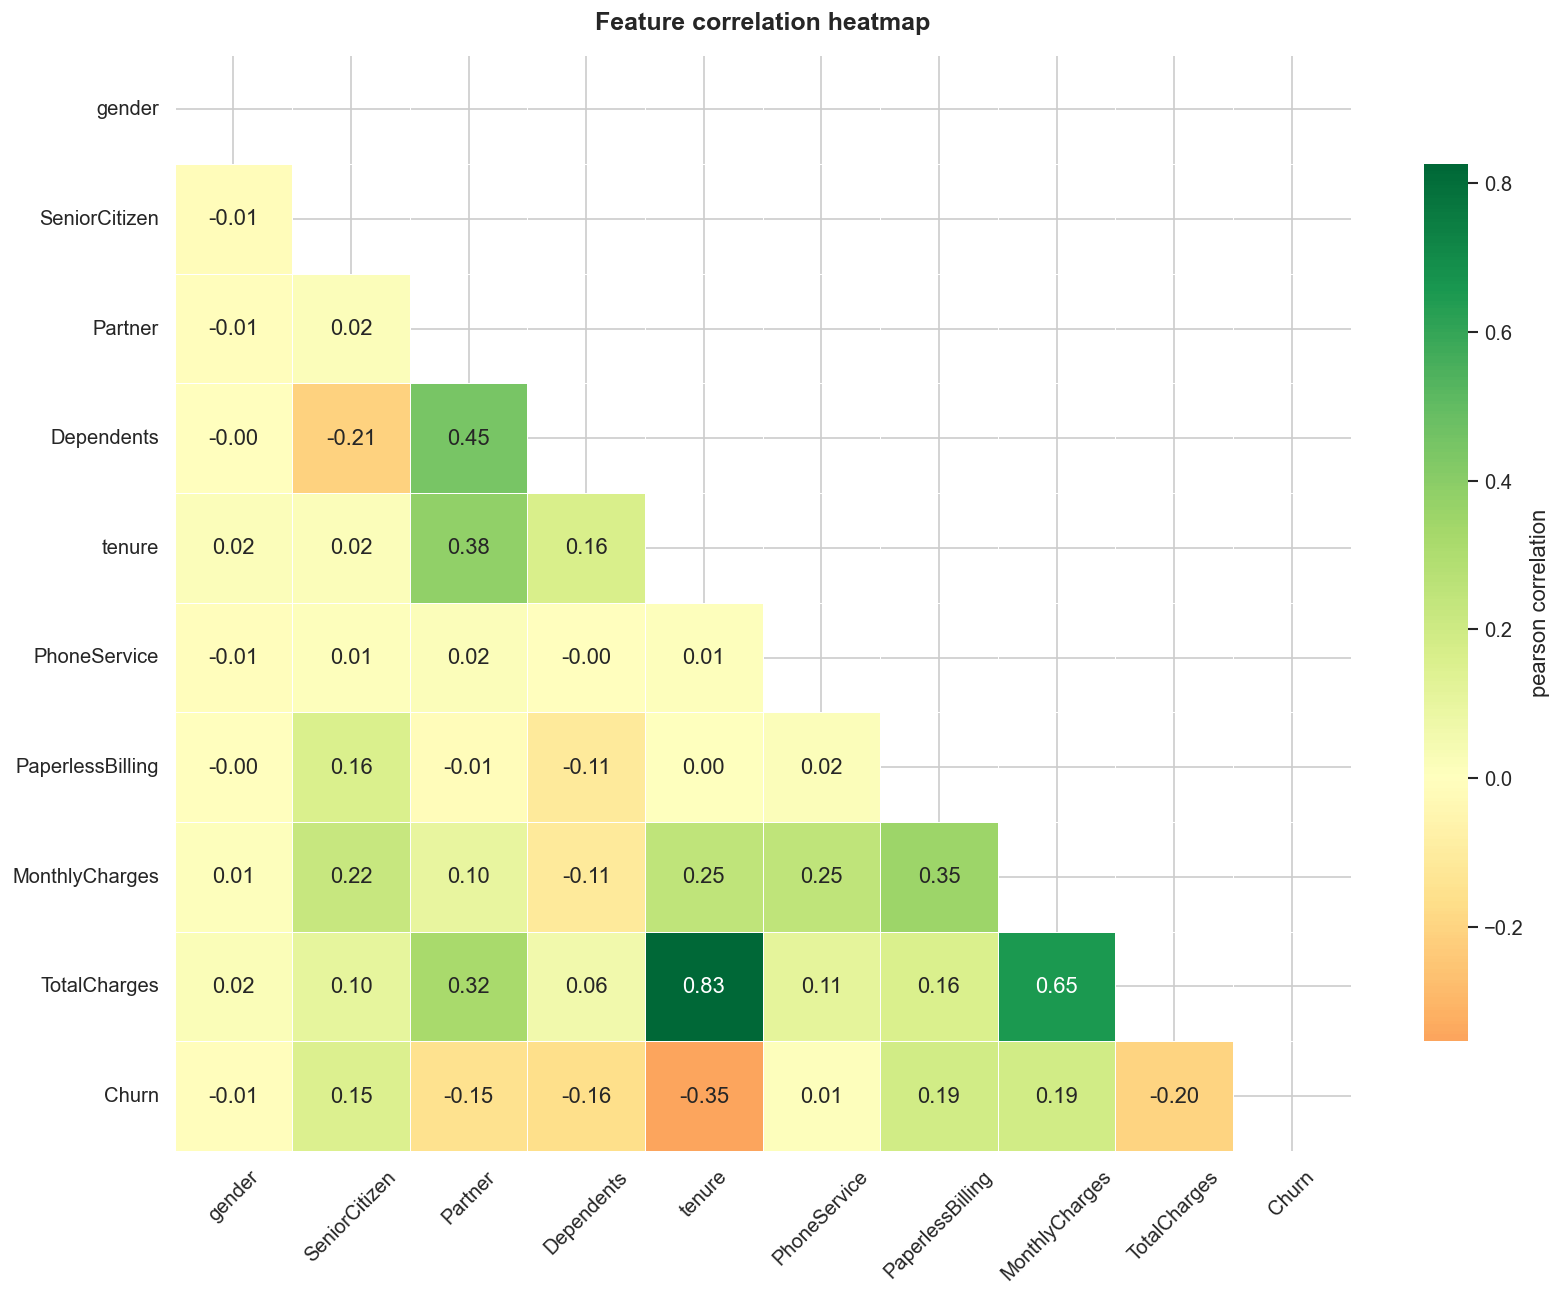

Saved: 05_correlation_heatmap.png


In [22]:
# Correlation heatmap of all numeric columns

numeric_df  = df.select_dtypes(include='number')
corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(14, 11))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask   = mask,
    annot  = True,
    fmt    = '.2f',
    cmap   = 'RdYlGn',
    center = 0,
    linewidths = 0.5,
    linecolor  = 'white',
    cbar_kws   = {'shrink': 0.8, 'label': 'pearson correlation'},
    ax = ax 
)

ax.set_title('Feature correlation heatmap',
             fontsize=15, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}05_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("Saved: 05_correlation_heatmap.png")

In [24]:
# Print the top correlations with the Churn column

churn_corr = (corr_matrix['Churn']
                .drop('Churn')
                .abs()
                .sort_values(ascending=False))

print("Feature correlations with churn (absolute value, ranked):")
print()
for feat, val in churn_corr.items():
    direction = "positive" if corr_matrix.loc[feat, 'Churn'] > 0 else "negative"
    bar       = "█" * int(val * 20)
    print(f" {feat:<25} {bar:<20} {val:.3f} ({direction})")

Feature correlations with churn (absolute value, ranked):

 tenure                    ███████              0.354 (negative)
 TotalCharges              ███                  0.199 (negative)
 MonthlyCharges            ███                  0.193 (positive)
 PaperlessBilling          ███                  0.191 (positive)
 Dependents                ███                  0.163 (negative)
 SeniorCitizen             ███                  0.151 (positive)
 Partner                   ██                   0.150 (negative)
 PhoneService                                   0.012 (positive)
 gender                                         0.009 (negative)


# Bivariate Analysis

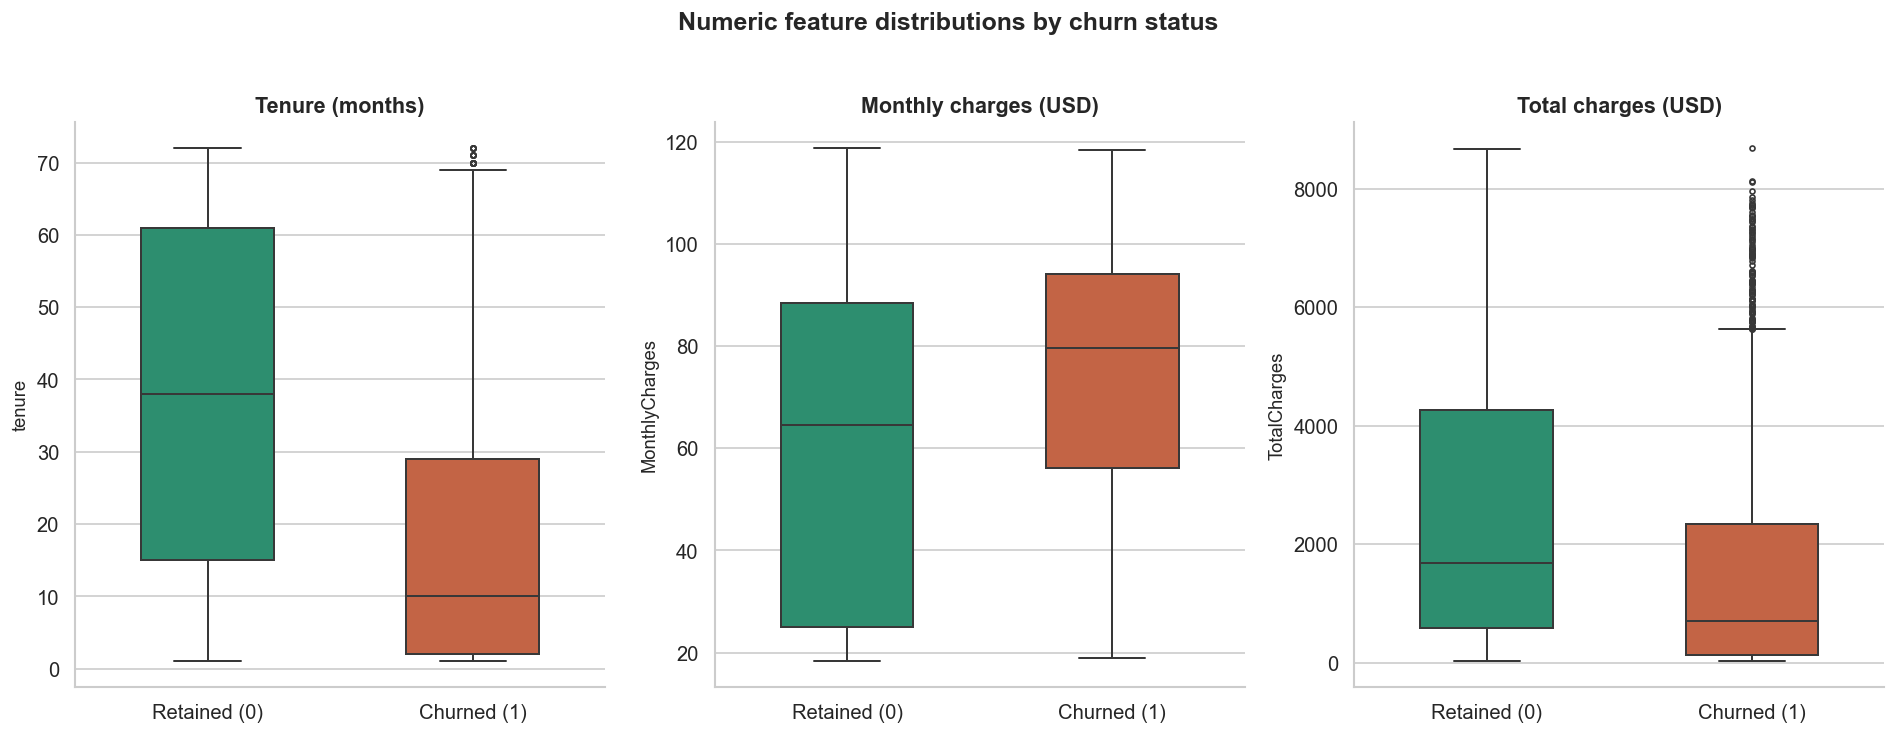

Saved: 06_boxplots_by_churn.png


In [26]:
# Boxplots: numeric features split by Churn status

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

churn_palette = {0: '#1D9E75', 1: '#D85A30'}
churn_labels  = {0: 'Retained', 1: 'Churned'}

for ax, col, title in zip(axes, numeric_cols, col_titles):
    sns.boxplot(data=df, x='Churn', y=col,
                hue='Churn', palette=churn_palette, width=0.5,
                linewidth=1.2, fliersize=3, legend=False, ax=ax)
    
    # Relabel x-axis ticks from 0/1 to Retained/Churned
    ax.set_xticklabels(['Retained (0)', 'Churned (1)'])
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(col, fontsize=11)
    sns.despine(ax=ax)

fig.suptitle('Numeric feature distributions by churn status',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}06_boxplots_by_churn.png', bbox_inches='tight')
plt.show()
print("Saved: 06_boxplots_by_churn.png")

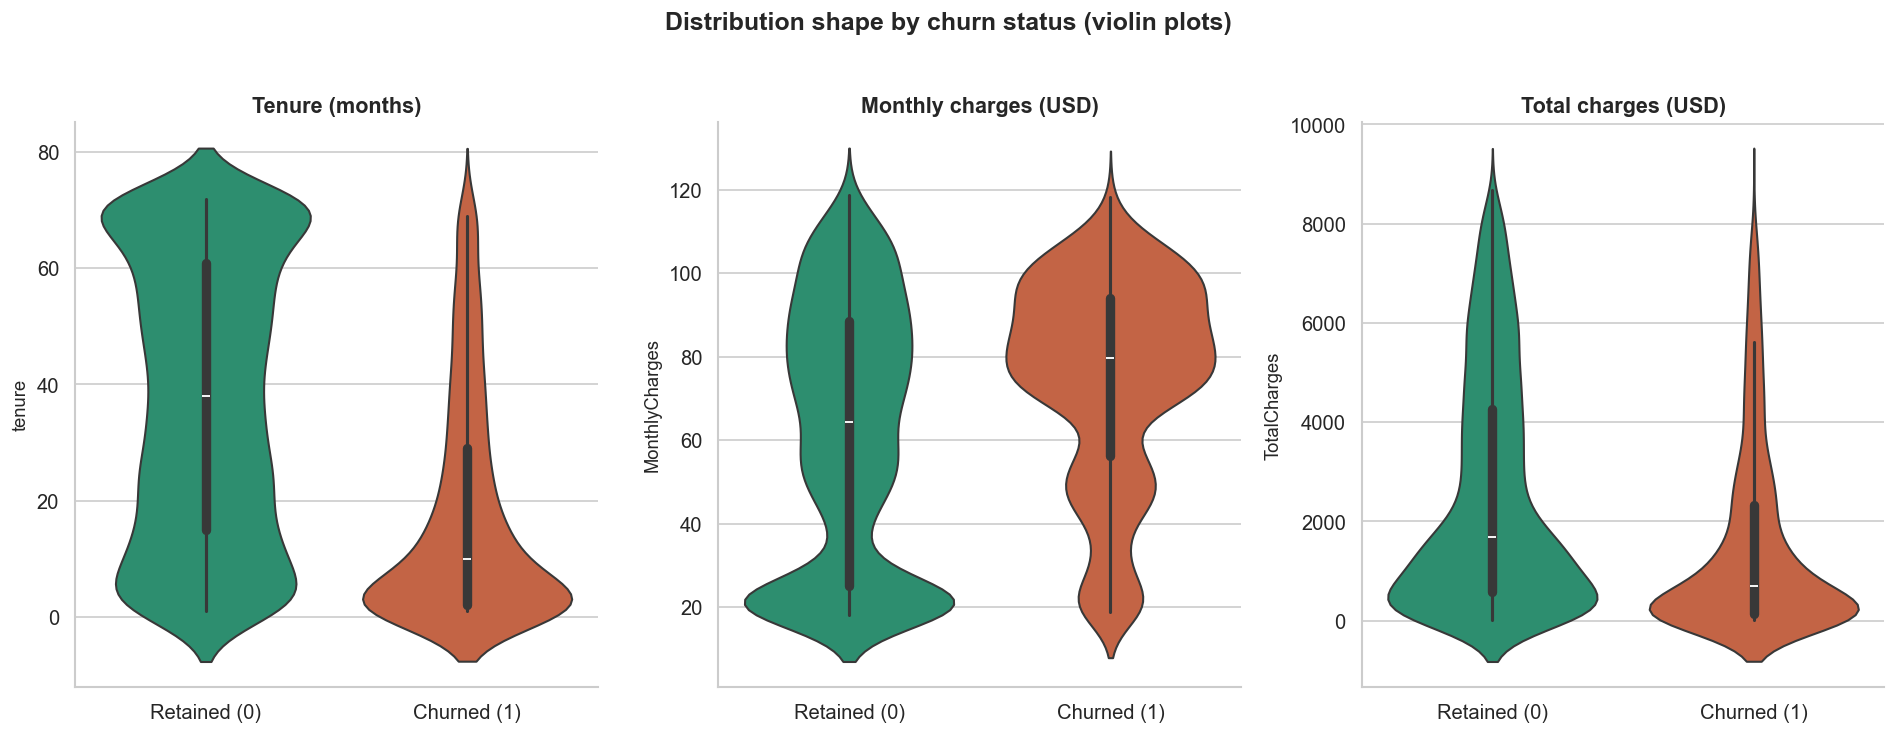

Saved: 07_violinplots_by_churn.png


In [28]:
# Violin plots for a richer view of distributions

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, col, title in zip(axes, numeric_cols, col_titles):
    sns.violinplot(data=df, x='Churn', y=col,
                   hue='Churn', palette=churn_palette,
                   inner='box',         # show a mini boxplot inside the violin
                   density_norm='width',
                   legend=False, ax=ax)
    ax.set_xticklabels(['Retained (0)', 'Churned (1)'])
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(col, fontsize=11)
    sns.despine(ax=ax)
    
fig.suptitle('Distribution shape by churn status (violin plots)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}07_violinplots_by_churn.png', bbox_inches='tight')
plt.show()
print("Saved: 07_violinplots_by_churn.png")

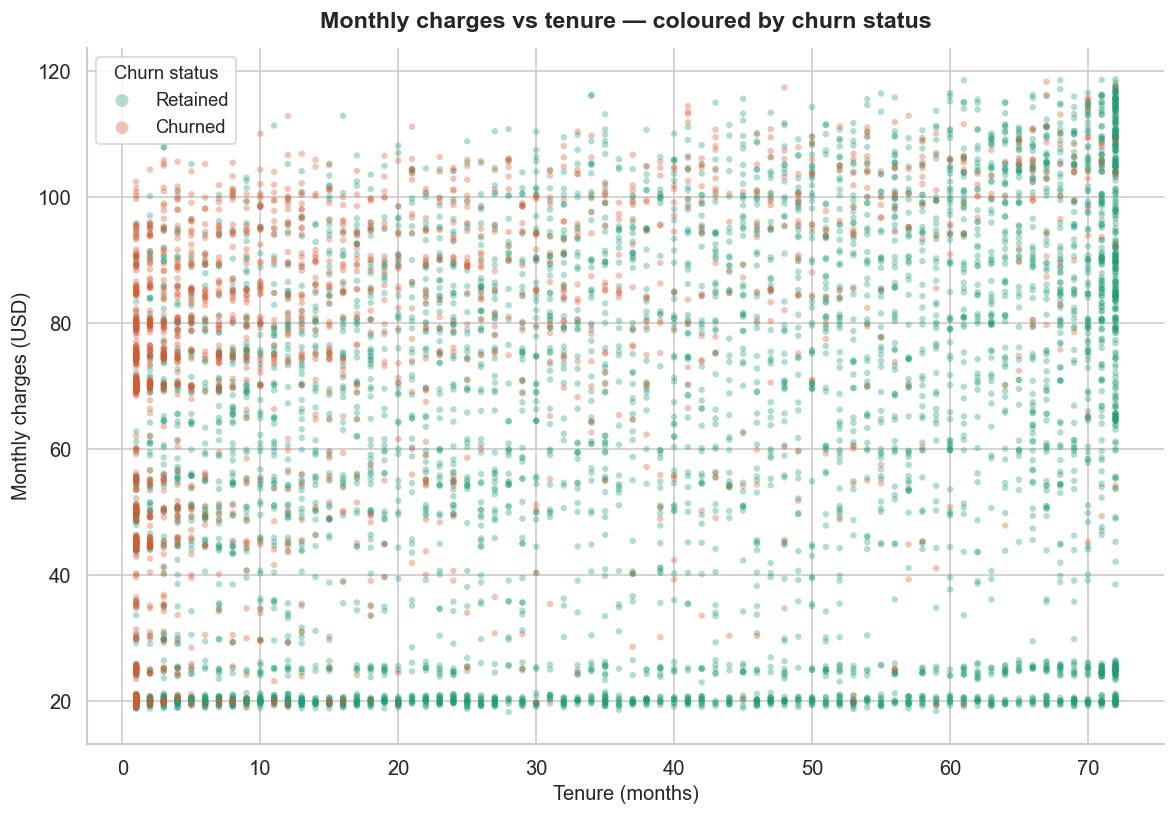

Saved: 08_scatter_tenure_charges.png


In [30]:
# Scatter plot: MonthlyCharges vs Tenure coloured by Churn

fig, ax = plt.subplots(figsize=(10, 7))

for churn_val, label, color in [(0, 'Retained', '#1D9E75'),
                                 (1, 'Churned', '#D85A30')]:
    subset = df[df['Churn'] == churn_val]
    ax.scatter(subset['tenure'], subset['MonthlyCharges'],
                   c=color, label=label, alpha=0.35,
                   s=15, edgecolors='none')
    
    ax.set_title('Monthly charges vs tenure — coloured by churn status',
                 fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('Tenure (months)', fontsize=12)
    ax.set_ylabel('Monthly charges (USD)', fontsize=12)
    ax.legend(title='Churn status', fontsize=11, title_fontsize=11,
              markerscale=2)
    sns.despine()

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}08_scatter_tenure_charges.png', bbox_inches='tight')
plt.show()
print("Saved: 08_scatter_tenure_charges.png")

# Key Insights Summary

In [31]:
# Print and document all key EDA findings\

print("=" * 65)
print(" STAGE 3 - KEY EDA FINDINGS")
print("=" * 65)

print("""
FINDING 1 — CLASS IMBALANCE
  Churn rate is 26.5% (1,869 of 7,032 customers).
  Imbalance ratio: ~2.7:1 (retained:churned).
  ACTION: Use class_weight='balanced' when training models in Stage 5.

FINDING 2 — TENURE IS THE STRONGEST PREDICTOR
  Customers in their first 12 months churn at ~47%.
  Customers past 60 months churn at under 6%.
  The scatter plot confirms: low tenure + high charges = highest risk.
  ACTION: tenure will be our most important feature.

FINDING 3 — CONTRACT TYPE IS CRITICAL
  Month-to-month contracts: ~43% churn rate.
  One-year contracts     :  ~11% churn rate.
  Two-year contracts     :   ~3% churn rate.
  ACTION: Contract type will be a top categorical predictor.

FINDING 4 — FIBER OPTIC CUSTOMERS CHURN MORE
  Fiber optic internet: ~42% churn rate.
  DSL internet        : ~19% churn rate.
  No internet service :  ~7% churn rate.
  ACTION: InternetService is a critical feature. Possible product issue.

FINDING 5 — HIGH MONTHLY CHARGES DRIVE CHURN
  Churned customers pay ~$74/month on average.
  Retained customers pay ~$61/month on average.
  This $13 gap is statistically and commercially significant.
  ACTION: MonthlyCharges is a strong numeric predictor.

FINDING 6 — MULTICOLLINEARITY NOTE
  TotalCharges and tenure are highly correlated (~0.83).
  TotalCharges and MonthlyCharges are also correlated (~0.65).
  ACTION: Consider dropping TotalCharges in Stage 4 to reduce
          redundancy, OR keep all three and let tree-based models
          handle the selection naturally.
""")
print("=" * 65)
print(f"  Figures saved: {FIGURES_PATH}")
print(f"  Total figures: {len(os.listdir(FIGURES_PATH))}")
print("=" * 65)

 STAGE 3 - KEY EDA FINDINGS

FINDING 1 — CLASS IMBALANCE
  Churn rate is 26.5% (1,869 of 7,032 customers).
  Imbalance ratio: ~2.7:1 (retained:churned).
  ACTION: Use class_weight='balanced' when training models in Stage 5.

FINDING 2 — TENURE IS THE STRONGEST PREDICTOR
  Customers in their first 12 months churn at ~47%.
  Customers past 60 months churn at under 6%.
  The scatter plot confirms: low tenure + high charges = highest risk.
  ACTION: tenure will be our most important feature.

FINDING 3 — CONTRACT TYPE IS CRITICAL
  Month-to-month contracts: ~43% churn rate.
  One-year contracts     :  ~11% churn rate.
  Two-year contracts     :   ~3% churn rate.
  ACTION: Contract type will be a top categorical predictor.

FINDING 4 — FIBER OPTIC CUSTOMERS CHURN MORE
  Fiber optic internet: ~42% churn rate.
  DSL internet        : ~19% churn rate.
  No internet service :  ~7% churn rate.
  ACTION: InternetService is a critical feature. Possible product issue.

FINDING 5 — HIGH MONTHLY CHAR

## EDA Complete

All 8 figures saved to `reports/figures/`. Key takeaways:
- Churn rate: 26.5% — class imbalance must be addressed in modelling
- Top predictors identified: `tenure`, `Contract`, `InternetService`, `MonthlyCharges`
- Critical segment at risk: new customers (0–12 months) on month-to-month fiber optic plans
- Next step: Stage 4 — Feature Engineering (one-hot encoding + scaling)